# Assignment 2

<br> 
    <p style="text-align:center;"><img src="https://upload.wikimedia.org/wikipedia/commons/0/0b/AbaloneInside.jpg" width="400"></p>
</br>

In the second assignment, you can revise **regression techniques** and your **Pandas skills**. 
For this, we consider a dataset of [ear shells](https://en.wikipedia.org/wiki/Abalone) as depicted above. You have encountered the first 23 entries of this dataset in the first assignment. With this notebook you can work on

* making proficient use of **Pandas** functions,
* **ridge regression**,
* regression with **decision trees**,
* and **random forest** regression.

For this exercise, you can switch back to the environment ```APML``` used during class.

Please provide solutions to all exercises below and send me all notebooks by **28th of June 2026**.

***

## Part I: Dataset overview

Let us first inspect the dataset. Load the data with the following cells.

In [1]:
import pandas as pd
import numpy as np

shell_data = pd.read_csv("data/shells.csv", sep=",")

In [2]:
shell_data.head(5)

,subset,sex,length,diameter,height,weight_whole,weight_shucked,weight_viscera,weight_shell,rings,price
0,train,I,0.349544,0.260194,0.074504,0.179963,0.089707,0.024760,0.054516,5.0,1.205721
1,train,F,0.545249,0.439866,0.134915,0.918132,0.428983,0.201751,0.237840,10.0,18.403463
2,test,F,0.649654,0.544545,0.175080,1.524459,0.590134,0.325970,0.495506,10.0,31.455767
3,train,I,0.500003,0.394566,0.140912,0.621133,0.292336,0.120165,0.195429,9.0,5.647747
4,train,I,0.439268,0.335001,0.110040,0.389429,0.175157,0.083279,0.110899,7.0,1.966989


In [3]:
shell_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3174 entries, 0 to 3173
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subset          3174 non-null   object 
 1   sex             3174 non-null   object 
 2   length          3160 non-null   float64
 3   diameter        3161 non-null   float64
 4   height          3158 non-null   float64
 5   weight_whole    3165 non-null   float64
 6   weight_shucked  3158 non-null   float64
 7   weight_viscera  3161 non-null   float64
 8   weight_shell    3156 non-null   float64
 9   rings           3125 non-null   float64
 10  price           3125 non-null   float64
dtypes: float64(9), object(2)
memory usage: 272.9+ KB


### Exercise I.1

As we want to employ regression techniques, encode the entries in 
```sex``` column with numerical values like
* ```0.0```, ```0.5```, and ```1.0``` instead of
* ```'M'```, ```'I'```, and ```'F'```.

Fill in the cell below:

In [4]:
# sex column with numeric values 0.0, 0.5, and 1.0 for M, I, and F respectively
shell_data["sex"] = shell_data["sex"].map({"M": 0.0, "I": 0.5, "F": 1.0})

If you were successful, the following cell should execute without an error:

In [5]:
shell_data["sex"] = shell_data["sex"].astype(float)
print(shell_data["sex"])

0       0.5
1       1.0
2       1.0
3       0.5
4       0.5
       ... 
3169    0.0
3170    0.5
3171    0.0
3172    0.0
3173    1.0
Name: sex, Length: 3174, dtype: float64


### Exercise I.2

Now, obtain the following statistics for the columns containing numerical values:

* count of non-NaN entries
* mean
* standard deviation
* minimum value
* 25% quantile
* 50% quantile (i.e. the median)
* 75% qunatile
* maximum value

In [6]:
stats = shell_data.describe()
stats

,sex,length,diameter,height,weight_whole,weight_shucked,weight_viscera,weight_shell,rings,price
count,3174.000000,3160.000000,3161.000000,3158.000000,3165.000000,3158.000000,3161.000000,3156.000000,3125.000000,3125.000000
mean,0.465186,0.516205,0.401336,0.138255,0.764037,0.343201,0.172050,0.215670,8.689920,12.024373
std,0.393335,0.131391,0.126263,0.084966,0.466387,0.220716,0.136621,0.133738,1.653047,8.963651
min,0.000000,0.094519,0.114609,0.000001,0.021138,0.007403,0.003511,0.005239,5.000000,0.100000
25%,0.000000,0.434565,0.330140,0.105771,0.382497,0.165102,0.081643,0.113109,8.000000,4.453396
50%,0.500000,0.525544,0.409506,0.135211,0.710930,0.312112,0.154211,0.200564,9.000000,10.034258
75%,1.000000,0.604580,0.474416,0.159917,1.086911,0.489907,0.238505,0.298070,10.000000,18.267589
max,1.000000,1.973813,3.491197,2.662290,2.987259,1.905003,3.196680,1.545075,11.000000,52.901790


### Exercise I.3

From the information above, you can already deduce that there are some **missing 
values**. 

1. Obtain the sub-table containing missing values.
2. From this, store the row indices with missing values in ```row_indices_nans```. We will make use of this later on.

Hints: Your solution could include the following parts

*  ```np.any()```
*  ```.isna()```
*  ```.index```

Note that your own solution might not require all of these.

In [7]:
# Find rows that have ANY missing value (True/False for each row)
has_missing = shell_data.isna().any(axis=1)

# 1. Sub-table containing only rows with missing values
sub_table = shell_data[has_missing]

# 2. Store the row indices of those rows
row_indices_nans = sub_table.index

In [8]:
print(row_indices_nans)

Int64Index([ 116,  142,  214,  265,  322,  437,  530,  531,  536,  557,  582,
             601,  705,  710,  725,  730,  735,  810,  886, 1042, 1152, 1271,
            1330, 1342, 1345, 1371, 1527, 1584, 2094, 2155, 2161, 2231, 2247,
            2327, 2334, 2618, 2636, 2691, 2801, 2809, 2833, 2858, 2865, 2867,
            2900, 2936, 3036, 3050, 3089],
           dtype='int64')


### Exercise I.4

Missing entries can pose a problem in your analysis when fitting, e.g., a regression model 
that expects a value for each property / column you provide. Thus, the first step in any analysis 
should be to treat these missing values. There are different ways to perform **imputation** of missing values.

In this exercise, set a column's **mean value** as the value for the missing entries in that column.

Hints: Your solution could include the following parts

* ```.isna()```
*  ```df.loc[row_index, column_name]```
  
Note that your own solution might not require all of these.

In [9]:
# Iterate over each column
for col in shell_data.columns:
    # Check if this column has any missing values
    if shell_data[col].isna().any():
        # Calculate the mean of this column (NaNs are ignored automatically)
        col_mean = shell_data[col].mean()

        # Find rows where THIS column is NaN
        missing_rows = shell_data[col].isna()

        # Fill those specific cells with the mean
        shell_data.loc[missing_rows, col] = col_mean

If you were successful, the following should not include missing values anymore:

In [10]:
shell_data.loc[row_indices_nans]

,subset,sex,length,diameter,height,weight_whole,weight_shucked,weight_viscera,weight_shell,rings,price
116,train,0.0,0.699990,0.524950,0.175067,1.758388,0.343201,0.361874,0.470646,8.68992,12.024373
142,train,0.5,0.370192,0.274717,0.138255,0.220267,0.094382,0.045334,0.064676,8.68992,12.024373
214,train,0.5,0.516205,0.401336,0.053713,0.791070,0.343201,0.172050,0.215670,8.68992,12.024373
265,train,0.5,0.516205,0.401336,0.075449,0.175988,0.079081,0.040844,0.050082,8.68992,12.024373
322,train,0.5,0.610429,0.465122,0.125543,0.764037,0.435620,0.189915,0.260209,8.68992,12.024373
437,train,0.0,1.834685,0.401336,1.343274,1.061885,0.459406,2.271939,1.164090,8.68992,12.024373
530,train,0.0,0.936320,0.177193,0.138255,0.716010,0.010560,2.052565,0.184903,8.68992,12.024373
531,train,0.5,0.819914,1.212821,0.480761,2.773814,0.542232,0.172050,0.215670,8.68992,12.024373
536,train,0.0,0.670178,0.401336,0.200330,1.595073,0.670799,0.384104,0.452039,8.68992,12.024373
557,train,0.5,0.594735,0.401336,0.154716,0.984314,0.343201,0.184089,0.215670,8.68992,12.024373


### Exercise I.5

In the following, we will try to predict the price of ear shells based on the different properties 
(which we will refer to as **features** in the following).

A first, simple metric is the (linear) **correlation** between the different features / columns of our dataset.

Obtain the **correlation matrix** for the numeric columns of ```shell_data```. Which features of ear shells 
correlate more strongly with the price?

In [11]:
# 1. Get the full correlation matrix (only numeric columns)
corr_matrix = shell_data.corr(numeric_only=True)
corr_matrix

# 2. Extract correlations with 'price' and sort
price_correlations = corr_matrix["price"].sort_values(ascending=False)
price_correlations

price             1.000000
weight_whole      0.926385
weight_shucked    0.900943
weight_shell      0.828945
length            0.756422
weight_viscera    0.702970
diameter          0.649230
rings             0.608344
height            0.356040
sex               0.220607
Name: price, dtype: float64

Note the top-3 features according to correlation matrix:
1. weight_whole
2. weight_shucked
3. weight_shell

***

## Part II: Ridge Regression

Before we start fitting different regression methods, let us first separate the 
```shell_data``` into four parts:

* ```shell_features_train```: The features we want to fit our models with. This table should not include the target ```'price'```.
* ```shell_targets_train```: The target ```'price'``` values we want to use to fit our models.
* ```shell_features_test```: The features we want to **test** our models on. This table should not include the target ```'price'```.
* ```shell_targets_test```: The **test prediction** target ```'price'``` values. 

In [12]:
shell_features_train = shell_data[shell_data["subset"] == "train"].copy()
shell_features_test = shell_data[shell_data["subset"] == "test"].copy()

shell_targets_train = shell_features_train["price"].copy()
shell_targets_test = shell_features_test["price"].copy()

shell_features_train = shell_features_train.drop(["subset", "price"], axis=1)
shell_features_test = shell_features_test.drop(["subset", "price"], axis=1)

shell_targets_test = shell_targets_test.to_frame()

print(
    f"Shapes of\n"
    f"shell_features_train:\t {shell_features_train.shape}\n"
    f"shell_features_test:\t {shell_features_test.shape}\n"
    f"shell_targets_train:\t {shell_targets_train.shape}\n"
    f"shell_targets_test:\t {shell_targets_test.shape}\n"
)

Shapes of
shell_features_train:	 (2857, 9)
shell_features_test:	 (317, 9)
shell_targets_train:	 (2857,)
shell_targets_test:	 (317, 1)



### Exercise II.1 

Implement a **ridge regression** approach to predict the ```'price'``` for the test set ```shell_features_test```.
Append the predicted prices to the ```shell_targets_test``` of true prices as an additional column.

In [13]:
from sklearn.linear_model import Ridge
import numpy as np

# 1. Create the Ridge regression model
ridgereg = Ridge(alpha=1.0)

# 2. Fit the model on training data
ridgereg.fit(shell_features_train, shell_targets_train)

# 3. Predict prices for the test set
predicted_prices = ridgereg.predict(shell_features_test)

# 4. Add predictions as a new column in shell_targets_test
shell_targets_test["ridge_predicted_price"] = np.around(predicted_prices, decimals=2)

In [14]:
shell_targets_test

,price,ridge_predicted_price
2,31.455767,26.76
9,2.284661,2.46
13,6.301808,9.62
15,8.615837,15.72
16,22.108901,21.11
...,...,...
3114,1.590018,2.31
3119,11.165964,12.78
3148,0.100000,0.83
3156,28.246706,29.21


### Exercise II.2

Can you think of a way to identify which features were more relevant in the ridge regression?

Fill in the cell below with your idea:

In [15]:
# Get the learned coefficients
coefficients = ridgereg.coef_

# Pair them with feature names
feature_importance = pd.Series(coefficients, index=shell_features_train.columns)

# Sort by absolute value (magnitude) — a large positive or negative weight means the feature matters a lot!
feature_importance.abs().sort_values(ascending=False)

weight_shucked    12.836137
weight_whole      12.258793
sex                4.774533
length             4.193867
weight_viscera     3.672029
height             3.362152
diameter           2.597544
weight_shell       0.836141
rings              0.319794
dtype: float64

Note the top-3 features according to the ridge regression:
1. weight_shucked
2. weight_whole
3. sex

***

## Part III: Decision Tree

### Exercise III.1

Implement a **decision tree** approach to predict the ```'price'``` for the test set ```shell_features_test```.
Append the predicted prices to the ```shell_targets_test``` of true prices as an additional column.

Use

In [16]:
tree_height = 5
random_state = 123

as the ```max_depth``` and ```random_state``` in the definition of your decision tree.

Fill in the cell below:

In [17]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# 1. Create the tree
tree_model = DecisionTreeRegressor(max_depth=tree_height, random_state=random_state)

# 2. Fit on training data
tree_model.fit(shell_features_train, shell_targets_train)

# 3. Predict on test data
tree_predictions = tree_model.predict(shell_features_test)

# 4. Append to shell_targets_test
shell_targets_test["Tree_predicted_price"] = np.around(tree_predictions, decimals=2)

Visualise the fitted tree below:

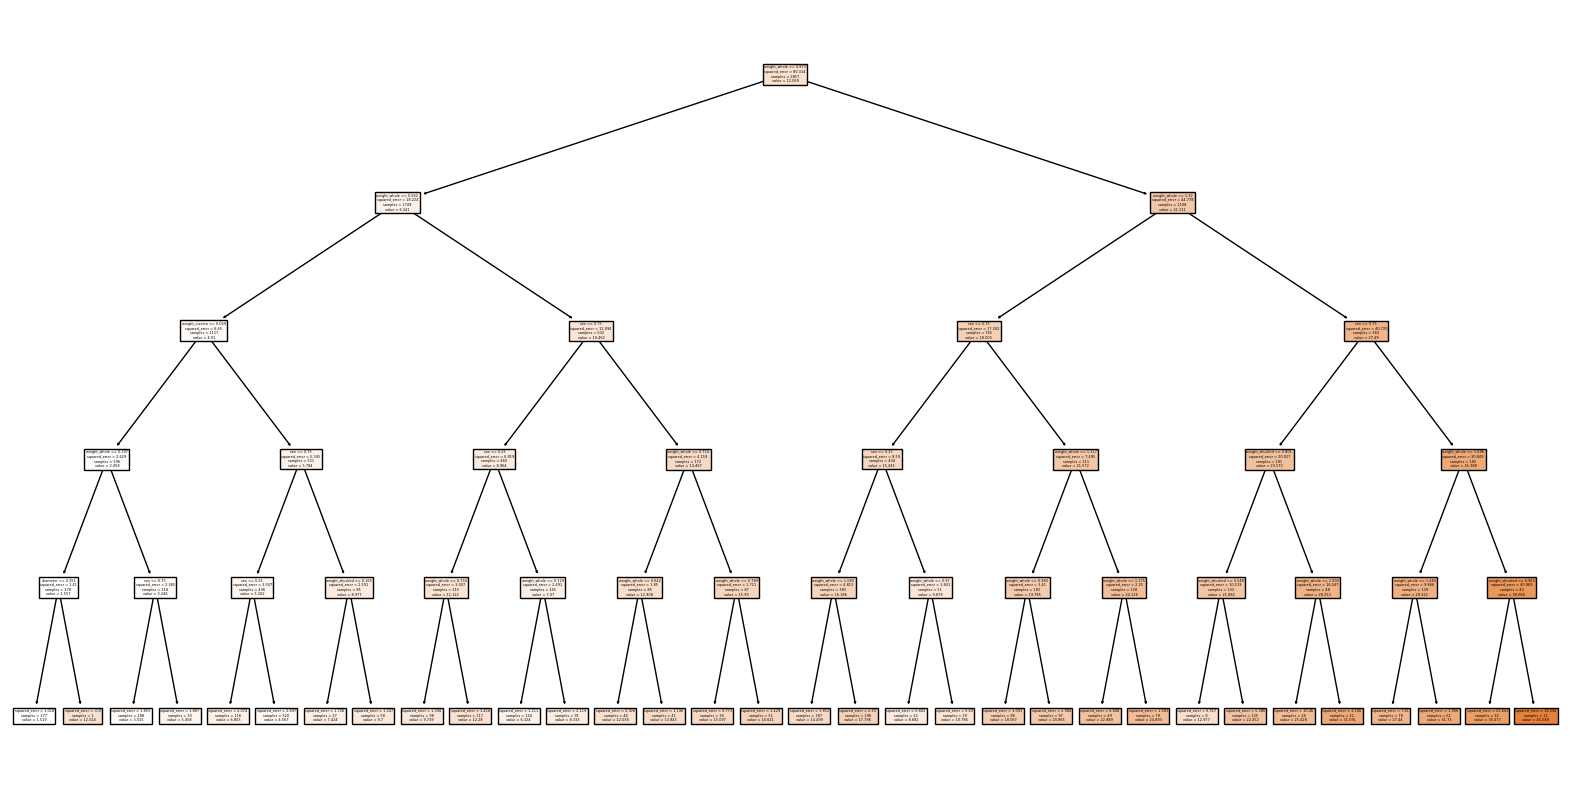

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(tree_model, feature_names=shell_features_train.columns, filled=True, ax=ax)
plt.show()

### Exercise III.2

Can you think of a way to identify which features were more relevant for the decision tree decision?

Fill in the cell below with your idea:

In [19]:
# Get built-in feature importances from the fitted forest
tree_importance = pd.Series(
    tree_model.feature_importances_, index=shell_features_train.columns
)

# Sort from most to least important
tree_importance.sort_values(ascending=False)

weight_whole      0.875648
sex               0.096362
weight_viscera    0.013831
weight_shucked    0.013665
diameter          0.000494
length            0.000000
height            0.000000
weight_shell      0.000000
rings             0.000000
dtype: float64

Note the top-3 features according to the decision tree:
1. weight_whole
2. sex
3. weight_viscera

***

## Part IV: Random Forest

### Exercise IV.1

Implement a **random forest** approach to predict the ```'price'``` for the test set ```shell_features_test```.
Append the predicted prices to the ```shell_targets_test``` of true prices as an additional column.

Similar to before, use 

In [20]:
tree_height = 5
random_state = 123
num_trees = 100

as the ```max_depth```, ```random_state```, and additional ```n_estimators``` in the definition of your random forest.

Fill in the cell below:

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Step 1: Create the Random Forest model
# n_estimators=100 means we build 100 different decision trees
# max_depth=5 means each tree can ask up to 5 questions deep
# random_state=123 makes the results reproducible every time you run it
rf_model = RandomForestRegressor(
    n_estimators=num_trees, max_depth=tree_height, random_state=random_state
)

# Step 2: Train (fit) the model on the training data
# The forest looks at shell_features_train and learns patterns from shell_targets_train
rf_model.fit(shell_features_train, shell_targets_train)

# Step 3: Predict prices for the test set
# The forest makes a prediction for every shell in the test set
rf_predictions = rf_model.predict(shell_features_test)

# Step 4: Add the predictions as a new column in shell_targets_test
# We round to 2 decimal places for readability
shell_targets_test["RF_predicted_price"] = np.around(rf_predictions, decimals=2)

Visualise a randomly selected fitted tree below:

Random integer between 0 and 99: 18


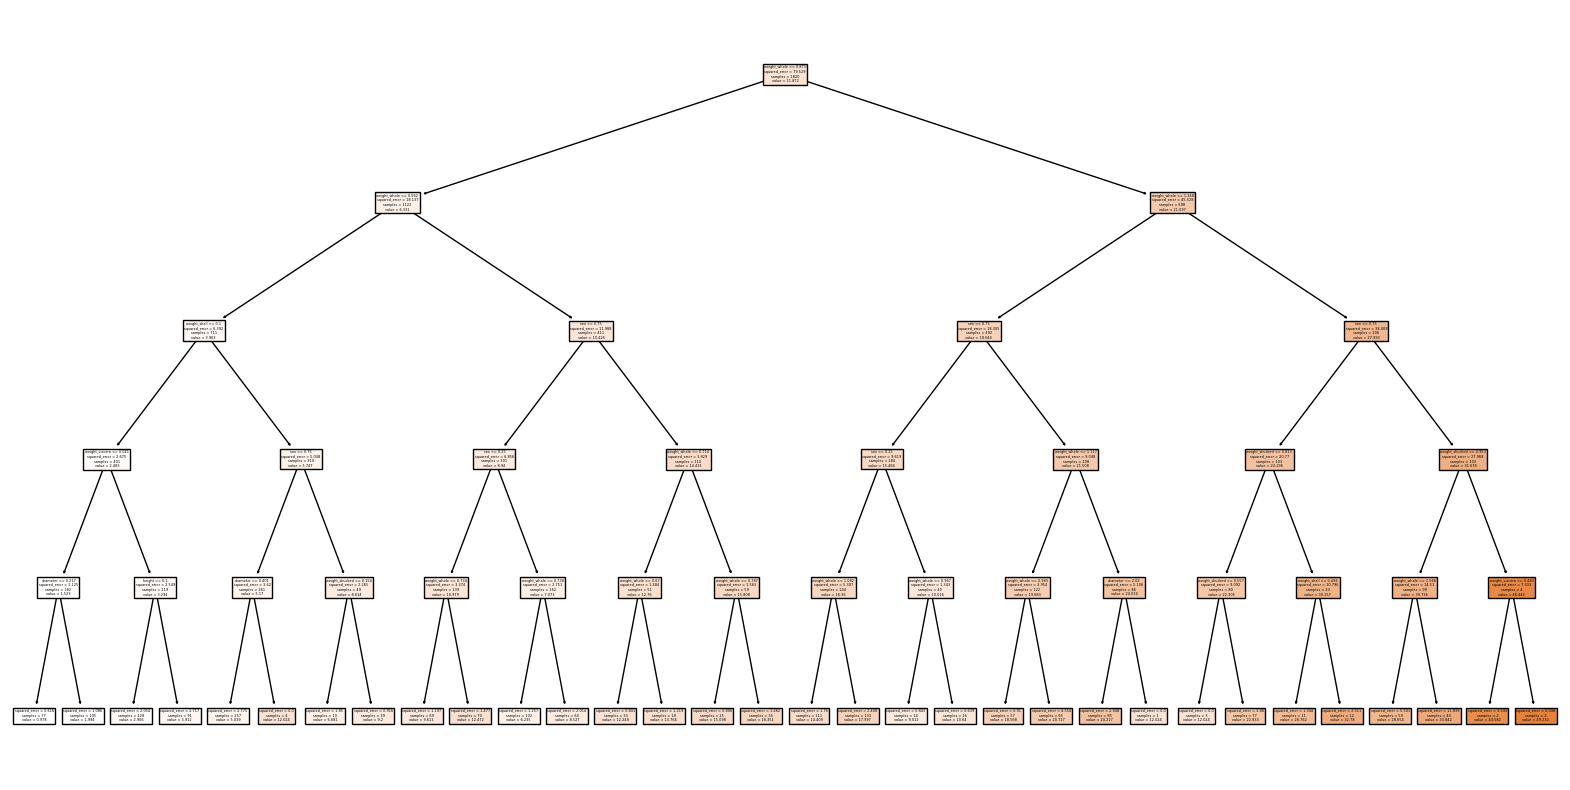

In [22]:
# get random integer from 0 and 99
import random

random_int = random.randint(0, 99)
print(f"Random integer between 0 and 99: {random_int}")
# Step 1: Pick one tree from the forest
# rf_model.estimators_ is a list of all 100 trees
random_tree = rf_model.estimators_[random_int]

# Step 2: Plot the tree
fig, ax = plt.subplots(figsize=(20, 10))  # Make it big so we can read it
plot_tree(
    random_tree,
    feature_names=shell_features_train.columns,  # Label the splits with real names
    filled=True,  # Color the boxes
    ax=ax,
)
plt.show()

### Exercise IV.2

Can you think of a way to identify which features were more relevant for the random forest decision?

Fill in the cell below with your idea:

In [23]:
# Step 1: Get the feature importances from the fitted random forest
# rf_model.feature_importances_ is the AVERAGE importance across all 100 trees
rf_importance = pd.Series(
    rf_model.feature_importances_, index=shell_features_train.columns
)

# Step 2: Sort from most important to least important
rf_importance.sort_values(ascending=False)

weight_whole      0.846598
sex               0.092148
weight_viscera    0.032666
weight_shucked    0.016435
weight_shell      0.005251
diameter          0.003656
length            0.001776
rings             0.000793
height            0.000678
dtype: float64

Note the top-3 features according to the random forest:
1. weight_whole
2. sex
3. weight_viscera

***

## Part V: Metric to compare methods

Which method performed best? Choose a metric which gives you a single number for the performance of each method on 
the test set ```shell_features_test```, i.e. compare ```shell_targets_test``` to the predictions.

By now, you should have collected all prediction results in the following table:

In [24]:
shell_targets_test

,price,ridge_predicted_price,Tree_predicted_price,RF_predicted_price
2,31.455767,26.76,31.73,30.06
9,2.284661,2.46,3.02,2.91
13,6.301808,9.62,6.32,6.03
15,8.615837,15.72,8.68,8.95
16,22.108901,21.11,20.87,21.53
...,...,...,...,...
3114,1.590018,2.31,3.02,2.72
3119,11.165964,12.78,13.84,13.23
3148,0.100000,0.83,1.52,1.11
3156,28.246706,29.21,27.44,30.94


Fill in the cell below with your metric:

In [25]:
from sklearn.metrics import mean_squared_error

# Get the true prices
true_prices = shell_targets_test["price"]

# Calculate MSE for each method
ridge_mse = mean_squared_error(true_prices, shell_targets_test["ridge_predicted_price"])
tree_mse = mean_squared_error(true_prices, shell_targets_test["Tree_predicted_price"])
rf_mse = mean_squared_error(true_prices, shell_targets_test["RF_predicted_price"])

print(f"Ridge Regression MSE:      {ridge_mse:.2f}")
print(f"Decision Tree MSE:         {tree_mse:.2f}")
print(f"Random Forest MSE:         {rf_mse:.2f}")  # winner!

Ridge Regression MSE:      6.11
Decision Tree MSE:         2.96
Random Forest MSE:         2.42


***

## Part VI: Missing values revisited

In the previous parts, we have devised different methods to predict the price given the features of ear shells.
With this, we have another option for imputation of missing values: We can predict the missing prices based on the features.

We reuse ```row_indices_nans``` from Exercise I.3 to define the rows for which we want to predict a better
value than just the mean price.

In [26]:
imputation_subset = shell_data.loc[row_indices_nans].copy()
imputation_features = imputation_subset.drop(["subset", "price"], axis=1)

In [27]:
imputation_features

,sex,length,diameter,height,weight_whole,weight_shucked,weight_viscera,weight_shell,rings
116,0.0,0.699990,0.524950,0.175067,1.758388,0.343201,0.361874,0.470646,8.68992
142,0.5,0.370192,0.274717,0.138255,0.220267,0.094382,0.045334,0.064676,8.68992
214,0.5,0.516205,0.401336,0.053713,0.791070,0.343201,0.172050,0.215670,8.68992
265,0.5,0.516205,0.401336,0.075449,0.175988,0.079081,0.040844,0.050082,8.68992
322,0.5,0.610429,0.465122,0.125543,0.764037,0.435620,0.189915,0.260209,8.68992
437,0.0,1.834685,0.401336,1.343274,1.061885,0.459406,2.271939,1.164090,8.68992
530,0.0,0.936320,0.177193,0.138255,0.716010,0.010560,2.052565,0.184903,8.68992
531,0.5,0.819914,1.212821,0.480761,2.773814,0.542232,0.172050,0.215670,8.68992
536,0.0,0.670178,0.401336,0.200330,1.595073,0.670799,0.384104,0.452039,8.68992
557,0.5,0.594735,0.401336,0.154716,0.984314,0.343201,0.184089,0.215670,8.68992


Now, drop these indices in the training set and test set, i.e. recreate ```shell_features_train```, 
```shell_targets_train```, ```shell_features_test```, ```shell_targets_test``` similar to the way
we have done above, but this time without the rows in ```imputation_features```.

Fill in the cell below:

In [28]:
# Step 1: Create clean train/test data that EXCLUDES the rows with missing values
shell_data_clean = shell_data.drop(row_indices_nans)

shell_features_train = shell_data_clean[shell_data_clean["subset"] == "train"].copy()
shell_features_test = shell_data_clean[shell_data_clean["subset"] == "test"].copy()

shell_targets_train = shell_features_train["price"].copy()
shell_targets_test = shell_features_test["price"].copy()

shell_features_train = shell_features_train.drop(["subset", "price"], axis=1)
shell_features_test = shell_features_test.drop(["subset", "price"], axis=1)

Rerun all cells above from Exercise II.1 on to retrain all methods, but this time we leave out all 
rows of ```imputation_features```. 

Finally, predict the results for ```price``` based on ```imputation_features``` with the different methods
and see how they differ from the mean value we imputed earlier.

Fill in the cell below:

In [29]:
# ============================================
# STEP 2: Retrain ALL models on clean data
# ============================================

# --- Ridge Regression ---
ridgereg = Ridge(alpha=1.0)
ridgereg.fit(shell_features_train, shell_targets_train)

# --- Decision Tree ---
tree_model = DecisionTreeRegressor(max_depth=tree_height, random_state=random_state)
tree_model.fit(shell_features_train, shell_targets_train)

# --- Random Forest ---
rf_model = RandomForestRegressor(
    n_estimators=num_trees, max_depth=tree_height, random_state=random_state
)
rf_model.fit(shell_features_train, shell_targets_train)


# ============================================
# STEP 3: Predict missing prices
# ============================================

# Predict prices for the rows that originally had missing values
ridge_missing = ridgereg.predict(imputation_features)
tree_missing = tree_model.predict(imputation_features)
rf_missing = rf_model.predict(imputation_features)

# Compare to the mean price we used in I.4
mean_price = shell_data["price"].mean()

print(f"Mean price (old imputation):  {mean_price:.2f}\n")

print("Predictions for first 5 missing rows:")
print(f"{'Row':<<8} {'Ridge':<<10} {'Tree':<<10} {'Forest':<<10}")
print("-" * 40)
for i, idx in enumerate(row_indices_nans[:5]):
    print(
        f"{idx:<8} {ridge_missing[i]:<<10.2f} {tree_missing[i]:<<10.2f} {rf_missing[i]:<<10.2f}"
    )

Mean price (old imputation):  12.02

Predictions for first 5 missing rows:
Row<<<<< Ridge<<<<< Tree<<<<<< Forest<<<<
----------------------------------------
116      28.22<<<<< 25.93<<<<< 25.85<<<<<
142      2.58<<<<<< 2.79<<<<<< 2.70<<<<<<
214      12.81<<<<< 8.15<<<<<< 7.85<<<<<<
265      -0.04<<<<< 1.85<<<<<< 1.98<<<<<<
322      11.37<<<<< 8.15<<<<<< 7.78<<<<<<


***

## Bonus Part VII: Larger trees

#### This last part is not required to complete assignment 2!

Above we used ```tree_height = 5```, i.e. up to five splits, to construct the trees. 
In Part V, you have defined a comparison metric, which should be three numbers for the
three regression techniques. Save your previous result by copying the outputs in the cell below:

Now, rerun the cells from Part III on, but this time with ```tree_height = 20```.

Does increasing the number of splits, in other words making more decisions, always help predict unseen test examples accurately? And if not, why is that not the case?